In [3]:
from matplotlib.pyplot import figure
from scipy.stats import norm
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt




In [4]:
data=pd.read_csv('anomaly_data.csv')
data.head()

,x1,x2
0,8.046815,9.741152
1,8.408520,8.763270
2,9.195915,10.853181
3,9.914701,11.174260
4,8.576700,9.042849


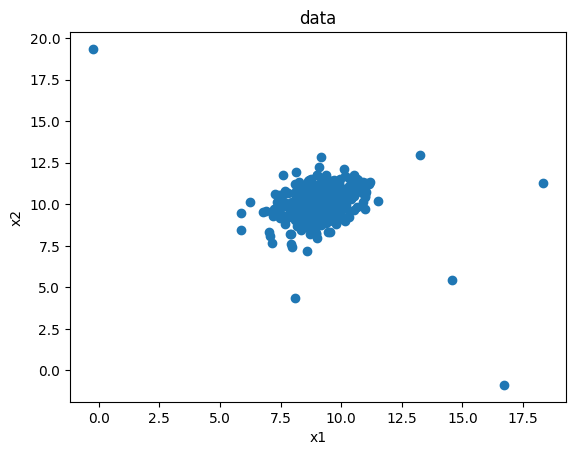

In [5]:
fig1=plt.figure()
plt.scatter(data.loc[:,'x1'],data.loc[:,'x2'])
plt.title('data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [6]:
x1=data.loc[:,'x1']
x2=data.loc[:,'x2']

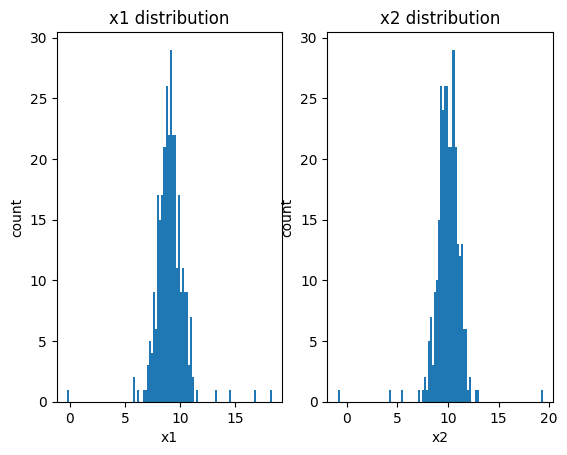

In [7]:
fig2=plt.figure()
plt.subplot(1,2,1)
plt.hist(x1,bins=100)
plt.title('x1 distribution')
plt.xlabel('x1')
plt.ylabel('count')
plt.subplot(1,2,2)
plt.hist(x2,bins=100)
plt.title('x2 distribution')
plt.xlabel('x2')
plt.ylabel('count')
plt.show()



In [8]:
x1_mean=x1.mean()
x1_sigma=x1.std()
x2_mean=x1.mean()
x2_sigma=x2.std()
print(x1_mean,x1_sigma,x2_mean,x2_sigma)

9.112225783931596 1.3559573758220915 9.112225783931596 1.30970711753864


In [9]:
from scipy.stats import norm
x1_range=np.linspace(0,20,300)
x1_normal=norm.pdf(x1_range,x1_mean,x1_sigma)
x2_range=np.linspace(0,20,300)
x2_normal=norm.pdf(x2_range,x2_mean,x2_sigma)

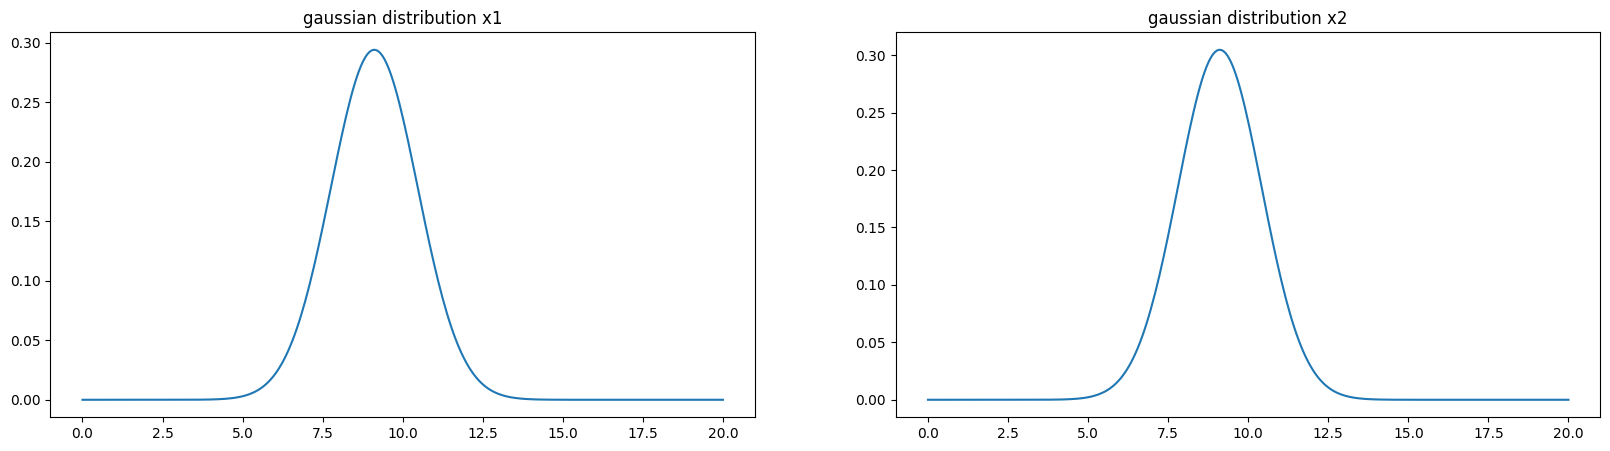

In [10]:
fig3=plt.figure(figsize=[20,5])
plt.subplot(1,2,1)
plt.plot(x1_range,x1_normal)
plt.title('gaussian distribution x1')
plt.subplot(1,2,2)
plt.plot(x2_range,x2_normal)
plt.title('gaussian distribution x2')
plt.show()


In [11]:
from sklearn.covariance import EllipticEnvelope
ad_model=EllipticEnvelope()
ad_model.fit(data)


,"store_precision store_precision: bool, default=TrueSpecify if the estimated precision is stored.",True
,"assume_centered assume_centered: bool, default=FalseIf True, the support of robust location and covariance estimatesis computed, and a covariance estimate is recomputed from it,without centering the data.Useful to work with data whose mean is significantly equal tozero but is not exactly zero.If False, the robust location and covariance are directly computedwith the FastMCD algorithm without additional treatment.",False
,"support_fraction support_fraction: float, default=NoneThe proportion of points to be included in the support of the rawMCD estimate. If None, the minimum value of support_fraction willbe used within the algorithm: `(n_samples + n_features + 1) / 2 * n_samples`.Range is (0, 1).",None
,"contamination contamination: float, default=0.1The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Range is (0, 0.5].",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines the pseudo random number generator for shufflingthe data. Pass an int for reproducible results across multiple functioncalls. See :term:`Glossary `.",None


In [12]:
y_predict=ad_model.predict(data)
print(pd.Series(y_predict).value_counts())

 1    276
-1     31
Name: count, dtype: int64


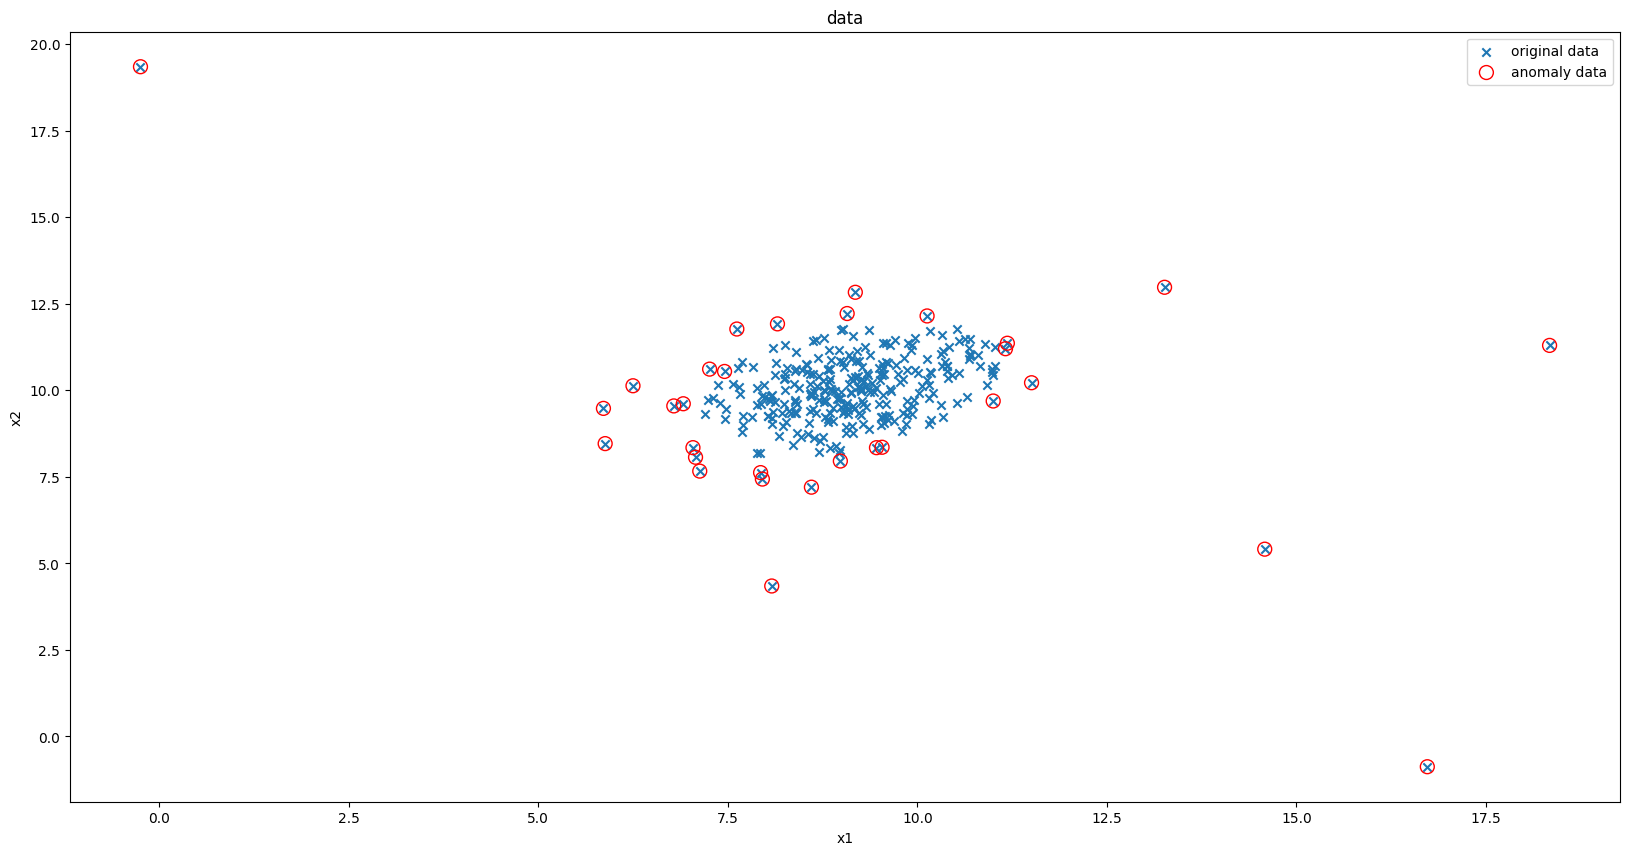

In [13]:

fig4 = plt.figure(figsize=[20,10])
original_data=plt.scatter(data.loc[:, 'x1'], data.loc[:, 'x2'],marker='x')
anomaly_data=plt.scatter(data.loc[:, 'x1'][y_predict==-1], data.loc[:, 'x2'][y_predict==-1],marker='o',facecolor='none',edgecolor='red',s=100)
plt.title('data')
plt.legend([original_data,anomaly_data],['original data','anomaly data'])
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [14]:
ad_model=EllipticEnvelope(contamination=0.05)
ad_model.fit(data)
y_predict=ad_model.predict(data)
print(pd.Series(y_predict).value_counts())

 1    291
-1     16
Name: count, dtype: int64


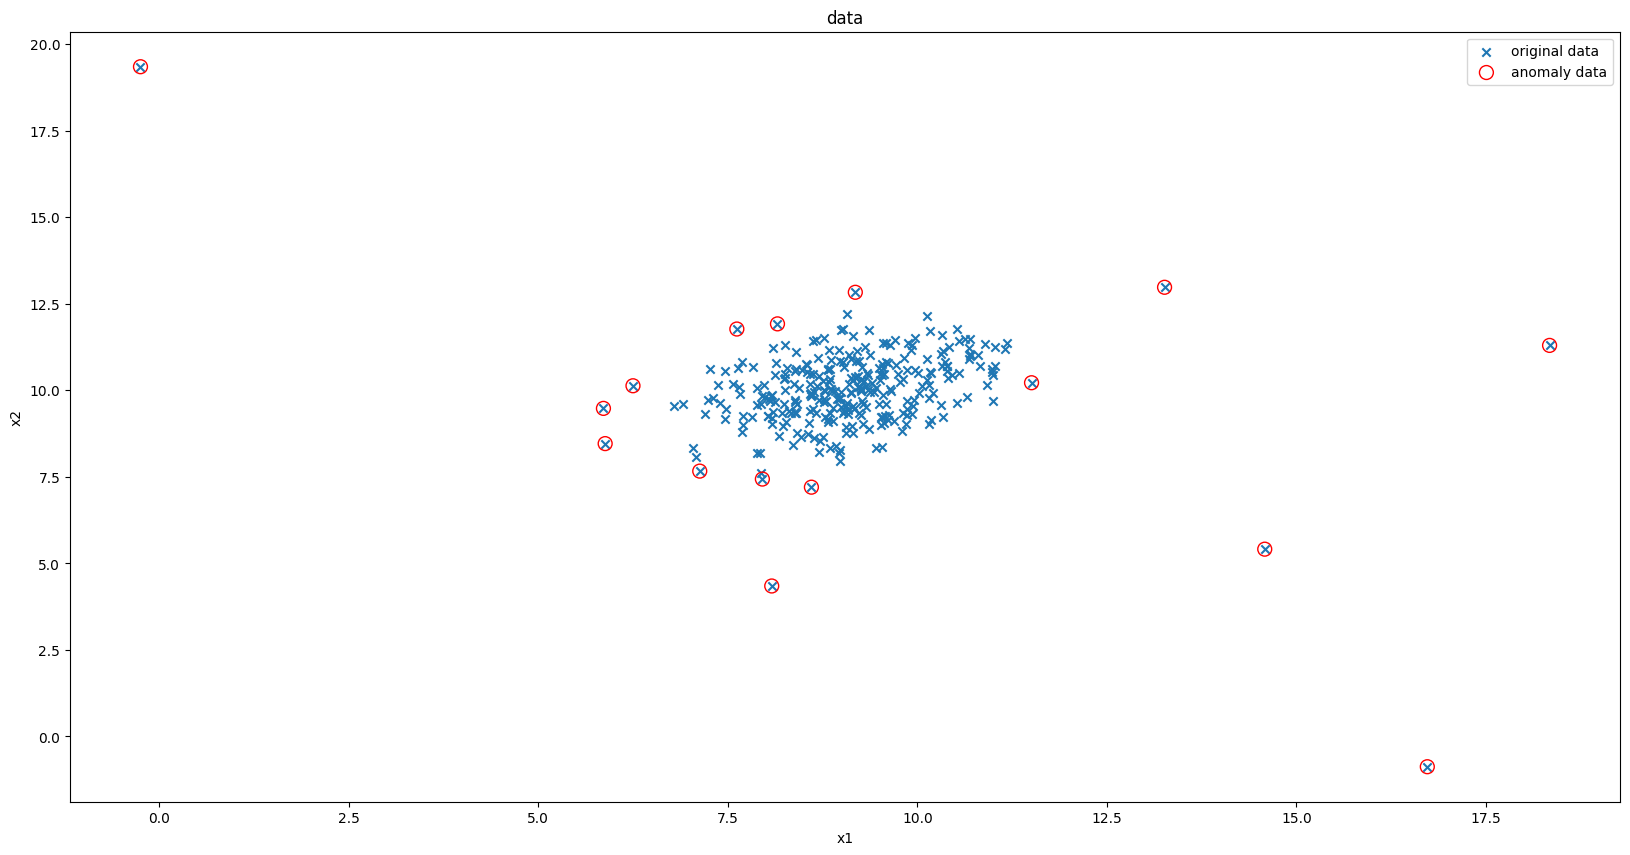

In [15]:
fig5 = plt.figure(figsize=[20,10])
original_data=plt.scatter(data.loc[:, 'x1'], data.loc[:, 'x2'],marker='x')
anomaly_data=plt.scatter(data.loc[:, 'x1'][y_predict==-1], data.loc[:, 'x2'][y_predict==-1],marker='o',facecolor='none',edgecolor='red',s=100)
plt.title('data')
plt.legend([original_data,anomaly_data],['original data','anomaly data'])
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()